# Fase 7 — EDA del dataset analítico maestro
DataJam Bogotá 2026 · pipeline `agent.md`

EDA exhaustivo sobre `gold/modelos/dataset_hipotesis_upz.parquet` (112 UPZ) y `dataset_hipotesis_localidad.parquet` (20 localidades). Para cada variable clave: distribución, tendencia central, dispersión, percentiles, asimetría, extremos, distribución espacial y temporal (donde aplica).

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

if os.path.exists("data"):
    BASE = os.path.abspath(".")
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(BASE, "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
GOLD = os.path.join(BASE, 'data', 'gold')
SILVER = os.path.join(BASE, 'data', 'silver')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

master_upz = pd.read_parquet(os.path.join(GOLD, 'modelos', 'dataset_hipotesis_upz.parquet'))
master_loc = pd.read_parquet(os.path.join(GOLD, 'modelos', 'dataset_hipotesis_localidad.parquet'))
gdf_upz = gpd.read_parquet(os.path.join(SILVER, 'territorio', 'upz.parquet'))
gdf_loc = gpd.read_parquet(os.path.join(SILVER, 'territorio', 'localidades.parquet'))
print(master_upz.shape, master_loc.shape)

(112, 27) (20, 35)


## 1. Estadística descriptiva — variables clave (UPZ, n=112)

In [2]:
vars_clave = ['n_puntos_criticos', 'densidad_puntos_criticos_km2', 'n_incidentes_total',
              'densidad_incidentes_km2', 'deficit_aseo_relativo', 'estrato_promedio_oficial',
              'n_cuadrantes', 'dist_estacion_bomberos_m']
desc = master_upz[vars_clave].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc['skew'] = master_upz[vars_clave].skew()
desc['n_extremos_iqr'] = [
    ((master_upz[c] < (master_upz[c].quantile(.25) - 1.5*(master_upz[c].quantile(.75)-master_upz[c].quantile(.25)))) |
     (master_upz[c] > (master_upz[c].quantile(.75) + 1.5*(master_upz[c].quantile(.75)-master_upz[c].quantile(.25))))).sum()
    for c in vars_clave
]
desc.round(2)

,count,mean,std,min,5%,25%,50%,75%,95%,max,skew,n_extremos_iqr
n_puntos_criticos,112.0,4.27,4.64,0.00,0.00,1.00,3.00,6.00,13.45,23.00,1.44,6
densidad_puntos_criticos_km2,112.0,1.26,1.36,0.00,0.00,0.12,0.97,1.89,3.65,8.67,1.94,1
n_incidentes_total,112.0,1477.68,793.15,56.00,306.95,871.00,1374.50,2003.25,2967.45,3222.00,0.33,0
densidad_incidentes_km2,112.0,472.32,327.19,8.06,66.30,294.76,410.61,563.24,1035.43,2047.67,2.21,7
deficit_aseo_relativo,112.0,-0.00,1.00,-2.58,-1.87,-0.65,0.16,0.76,1.31,1.38,-0.65,0
estrato_promedio_oficial,112.0,2.81,1.10,1.00,1.13,2.00,2.82,3.32,5.15,5.94,0.73,6
n_cuadrantes,112.0,13.03,6.06,2.00,6.00,9.00,12.00,16.00,25.00,32.00,0.99,5
dist_estacion_bomberos_m,112.0,2126.50,1120.23,213.59,502.55,1366.94,2096.09,2750.30,3596.86,7603.84,1.28,3


**Lectura:** `n_puntos_criticos` y `n_incidentes_total` muestran asimetría positiva fuerte (pocas UPZ concentran valores muy altos) — típico de variables de conteo espacial, consistente con la necesidad de modelos Poisson/BN (no lineales) usada en la Fase 10.

## 2. Distribuciones — histogramas y boxplots

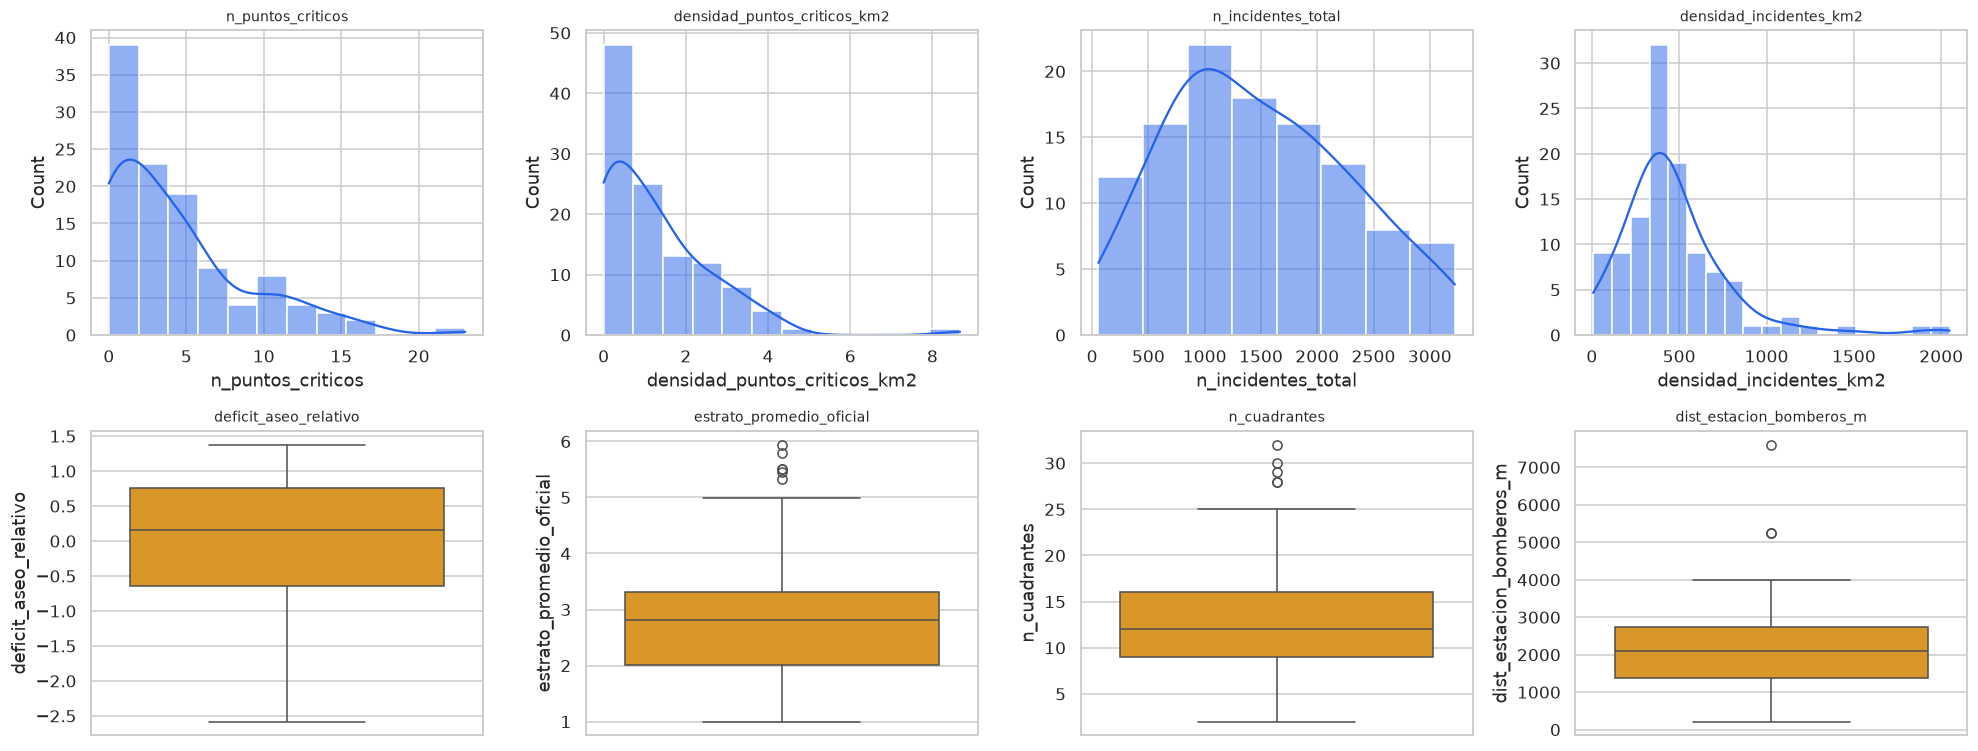

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes[0], vars_clave[:4]):
    sns.histplot(master_upz[c].dropna(), kde=True, ax=ax, color='#2563eb')
    ax.set_title(c, fontsize=9)
for ax, c in zip(axes[1], vars_clave[4:8]):
    sns.boxplot(y=master_upz[c].dropna(), ax=ax, color='#f59e0b')
    ax.set_title(c, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_01_distribuciones.png'), dpi=110)
plt.show()

## 3. Matriz de correlación (Spearman, robusta a no-normalidad)

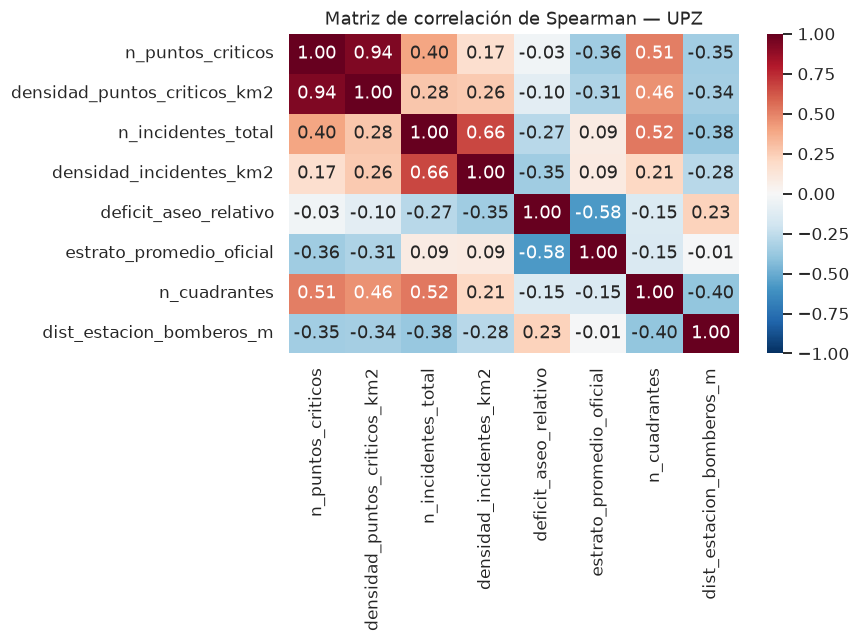

In [4]:
corr = master_upz[vars_clave].corr(method='spearman')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
plt.title('Matriz de correlación de Spearman — UPZ')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_02_correlacion.png'), dpi=110)
plt.show()

## 4. Scatterplots — pares clave para H1-H7

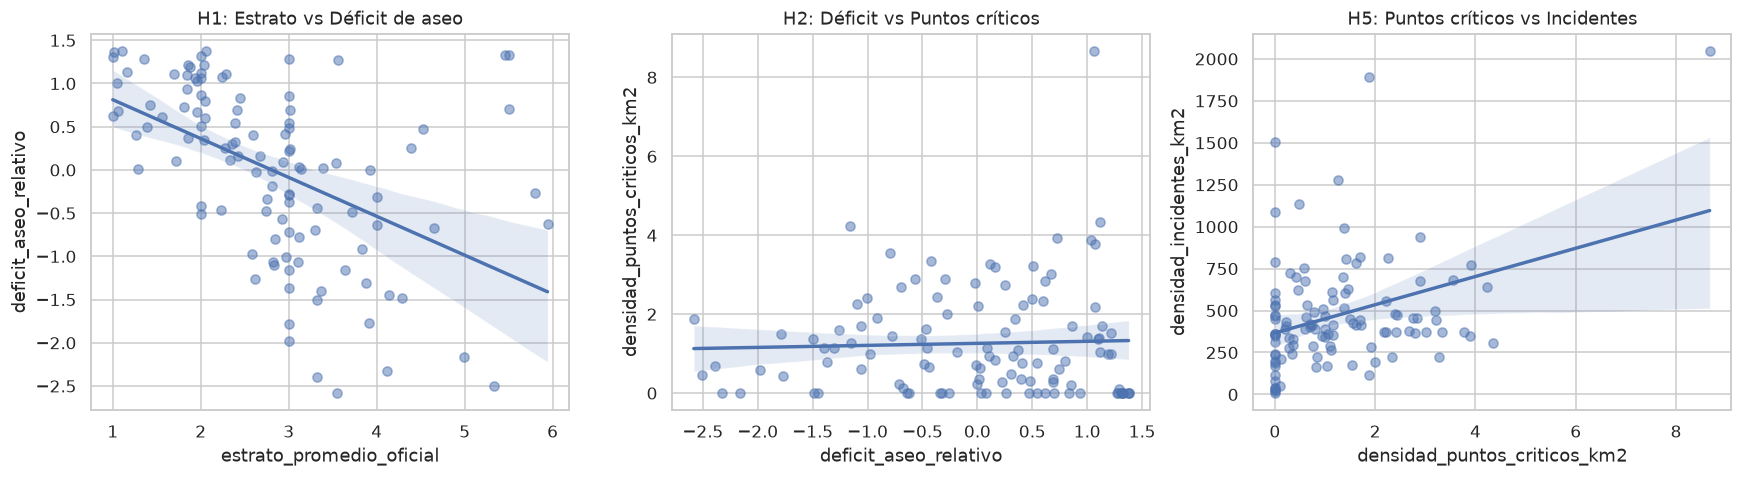

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.regplot(data=master_upz, x='estrato_promedio_oficial', y='deficit_aseo_relativo', ax=axes[0], scatter_kws={'alpha':0.5})
axes[0].set_title('H1: Estrato vs Déficit de aseo')
sns.regplot(data=master_upz, x='deficit_aseo_relativo', y='densidad_puntos_criticos_km2', ax=axes[1], scatter_kws={'alpha':0.5})
axes[1].set_title('H2: Déficit vs Puntos críticos')
sns.regplot(data=master_upz, x='densidad_puntos_criticos_km2', y='densidad_incidentes_km2', ax=axes[2], scatter_kws={'alpha':0.5})
axes[2].set_title('H5: Puntos críticos vs Incidentes')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_03_scatterplots.png'), dpi=110)
plt.show()

## 5. Mapas coropléticos — distribución espacial

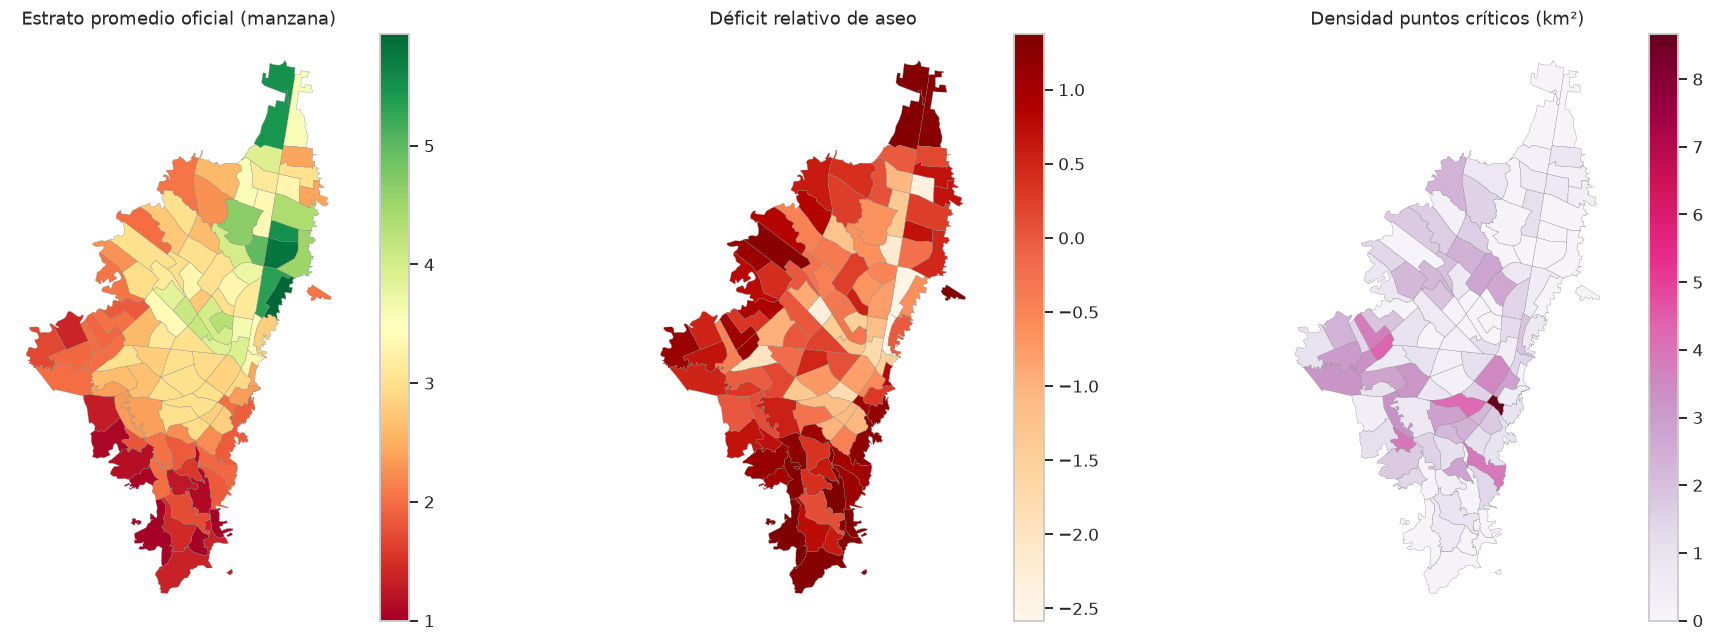

In [6]:
gdf_plot = gdf_upz.merge(master_upz, on=['cod_upz', 'nombre_upz', 'area_km2'], how='left')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
gdf_plot.plot(column='estrato_promedio_oficial', cmap='RdYlGn', legend=True, ax=axes[0], edgecolor='grey', linewidth=0.2)
axes[0].set_title('Estrato promedio oficial (manzana)')
gdf_plot.plot(column='deficit_aseo_relativo', cmap='OrRd', legend=True, ax=axes[1], edgecolor='grey', linewidth=0.2)
axes[1].set_title('Déficit relativo de aseo')
gdf_plot.plot(column='densidad_puntos_criticos_km2', cmap='PuRd', legend=True, ax=axes[2], edgecolor='grey', linewidth=0.2)
axes[2].set_title('Densidad puntos críticos (km²)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_04_mapas_coropleticos.png'), dpi=110)
plt.show()

## 6. Mapa de puntos — cestas, puntos críticos, estaciones bomberos

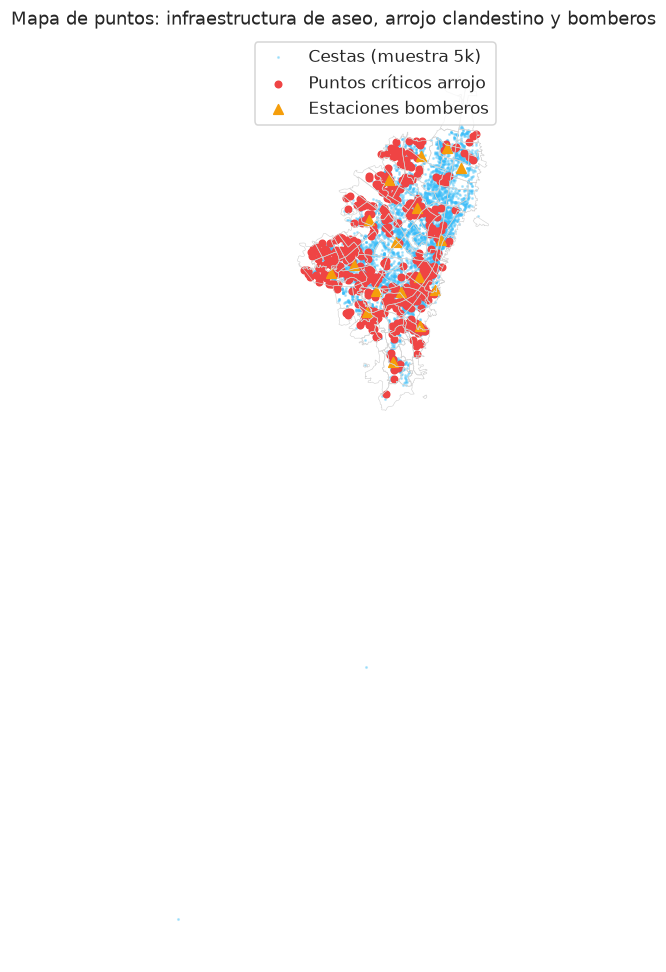

In [7]:
gdf_cestas = gpd.read_parquet(os.path.join(SILVER, 'aseo', 'cestas.parquet'))
gdf_pc = gpd.read_parquet(os.path.join(SILVER, 'aseo', 'puntos_criticos.parquet'))
gdf_ebom = gpd.read_parquet(os.path.join(SILVER, 'bomberos', 'estaciones.parquet'))

fig, ax = plt.subplots(figsize=(9, 9))
gdf_upz.boundary.plot(ax=ax, color='lightgrey', linewidth=0.4)
gdf_cestas.sample(min(5000, len(gdf_cestas)), random_state=42).plot(ax=ax, markersize=1, color='#38bdf8', alpha=0.3, label='Cestas (muestra 5k)')
gdf_pc.plot(ax=ax, markersize=18, color='#ef4444', label='Puntos críticos arrojo')
gdf_ebom.plot(ax=ax, markersize=40, color='#f59e0b', marker='^', label='Estaciones bomberos')
ax.set_title('Mapa de puntos: infraestructura de aseo, arrojo clandestino y bomberos')
ax.axis('off')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_05_mapa_puntos.png'), dpi=110)
plt.show()

## 7. Distribución temporal — RBL, UAECOB, Delitos (cada uno en su grano nativo)

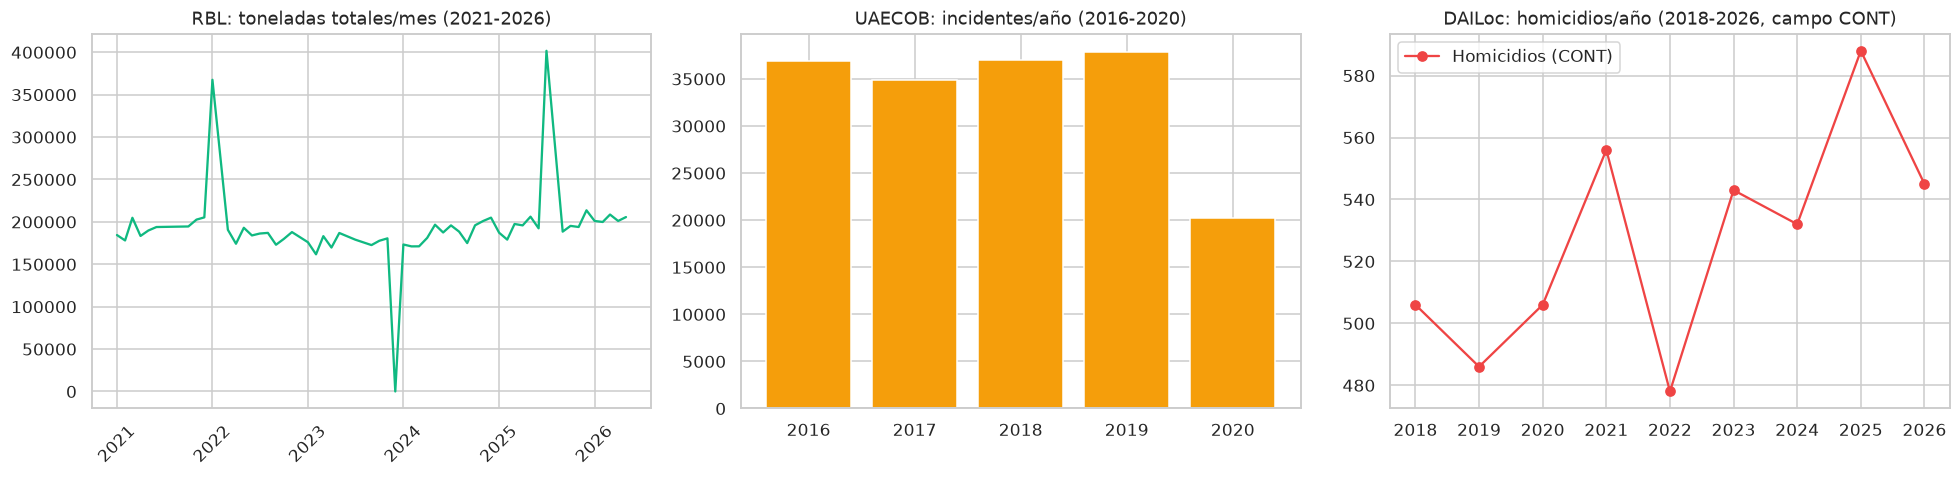

      homicidios  violencia_intrafamiliar
anio                                     
2018       506.0                  18547.0
2019       486.0                  16182.0
2020       506.0                  18661.0
2021       556.0                  17166.0
2022       478.0                  18575.0
2023       543.0                  13287.0
2024       532.0                  18830.0
2025       588.0                  19702.0
2026       545.0                  25631.0


In [8]:
df_rbl = pd.read_parquet(os.path.join(SILVER, 'aseo', 'rbl_series.parquet'))
df_inc = pd.read_parquet(os.path.join(SILVER, 'emergencias', 'incidentes_uaecob.parquet'))
df_delitos_anio = pd.read_parquet(os.path.join(GOLD, 'seguridad', 'delitos_localidad_anio.parquet'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
rbl_m = df_rbl.groupby('fecha')['total_t'].sum()
axes[0].plot(rbl_m.index, rbl_m.values, color='#10b981')
axes[0].set_title('RBL: toneladas totales/mes (2021-2026)')
axes[0].tick_params(axis='x', rotation=45)

inc_y = df_inc.groupby('anio').size()
axes[1].bar(inc_y.index.astype(str), inc_y.values, color='#f59e0b')
axes[1].set_title('UAECOB: incidentes/año (2016-2020)')

del_y = df_delitos_anio.groupby('anio')[['homicidios', 'violencia_intrafamiliar']].sum()
axes[2].plot(del_y.index, del_y['homicidios'], marker='o', label='Homicidios (CONT)', color='#ef4444')
axes[2].set_title('DAILoc: homicidios/año (2018-2026, campo CONT)')
axes[2].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_06_series_temporales.png'), dpi=110)
plt.show()
print(del_y)

**Nota de cobertura temporal:** RBL, UAECOB y DAILoc tienen ventanas temporales distintas y no solapadas del todo (2021-2026 / 2016-2020 / 2018-2026). No existe un único año común a las tres fuentes con las tres variables — limitación documentada también en `02_auditoria/reporte_auditoria.md`.